# **情感特征对股价预测的贡献**

本 notebook 验证 FinBERT 情感特征是否能提升 Random Forest 对次日股价涨跌的预测效果。

## 实验框架

- 与 E1 baseline 保持一致：相同的 10 个技术指标（计算方式逐行对齐 E1 源码）、相同的 Random Forest 超参数、相同的标签定义（`shift(-1)` 次日涨跌）、相同的 per-stock 80/20 时序划分，相同的池化建模（即所有股票合并训练一个模型）。池化建模将多只股票的数据合并训练，使模型学习跨股票共享的通用规律，例如技术指标形态与次日涨跌之间的普遍关联。相比 per-stock 独立建模，池化能显著扩大训练样本量。
- **日期限定在 2014-01 ~ 2015-12（推文覆盖期），确保情感特征有实际数据支撑**


## 输入特征

情感特征来自 Notebook 01（`01_sentiment_scoring.ipynb`），使用 FinBERT 对每只股票每日的 Twitter 推文进行情感打分，聚合为 stock-day 级别的统计量，保存于 `cache/daily_sentiment.pkl`。

三组特征对比：

| 变体 | 输入特征 | 维度 | 说明 |
|------|---------|------|------|
| **Tech-Only** | 10 个 technical indicators | 10 | E1 的原始 baseline |
| **Tech+Slim** | 10 tech + `positive_mean`, `negative_mean`, `tweet_count` | 13 | 精简情感：正面/负面均值 + 推文量 |
| **Tech+Full** | 10 tech + 14 维完整 FinBERT 情感统计 | 24 | 完整情感：含 min/max/mean/median × 3 类 + tweet_count + rel_volume |

## 实验设计

在与 E1 完全一致的实验框架下，通过对比 Tech-Only、Tech+Slim、Tech+Full 三组特征在 4 只高推文覆盖率股票和 87 只全量股票上的表现，验证 FinBERT 情感特征的增量贡献及其对推文覆盖率的依赖性。

| 实验 | 股票数 | 推文覆盖率 | 研究问题 |
|------|--------|-----------|---------|
| **实验 A** | 4 只（AAPL, AMZN, BABA, GOOG） | ~94% | 在推文覆盖充分的理想条件下，情感特征能否提升预测效果？ |
| **实验 B** | 87 只（全部） | ~45% | 当股票池扩大、推文覆盖率下降时，情感特征是否仍然有效？ |

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, matthews_corrcoef, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

PRICE_DIR = os.path.join('..', 'Data', 'price', 'preprocessed')
CACHE_DIR = os.path.join('..', 'cache')
OUTPUT_DIR = os.path.join('..', 'output_ablation')
os.makedirs(OUTPUT_DIR, exist_ok=True)

---
## **公共模块：数据加载、特征计算、模型定义**

In [4]:
def load_price_data(price_dir, stocks=None):
    """Load price data. If stocks is None, load all."""
    cols = ['date', 'movement_pct', 'open', 'high', 'low', 'close', 'volume']
    all_prices = []
    for fname in sorted(os.listdir(price_dir)):
        if not fname.endswith('.txt'): continue
        stock = fname.replace('.txt', '')
        if stocks is not None and stock not in stocks: continue
        df = pd.read_csv(os.path.join(price_dir, fname), sep='\t', header=None, names=cols)
        df['stock'] = stock
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        all_prices.append(df)
    return pd.concat(all_prices, ignore_index=True)


def compute_technical_indicators(df):
    """E1-consistent 10 technical indicators, per stock."""
    result_list = []
    for stock, group in df.groupby('stock'):
        g = group.copy()
        close = g['close'].values.astype(float)
        volume = g['volume'].values.astype(float)
        ma5 = pd.Series(close).rolling(5, min_periods=5).mean()
        ma20 = pd.Series(close).rolling(20, min_periods=20).mean()
        g['MA5'] = ma5.values
        g['MA20'] = ma20.values
        g['MA5_MA20_ratio'] = np.where(np.abs(ma20.values) > 1e-10,
                                       ma5.values / ma20.values, np.nan)
        delta = pd.Series(close).diff()
        gain = delta.clip(lower=0); loss = (-delta).clip(lower=0)
        avg_gain = gain.rolling(14, min_periods=14).mean()
        avg_loss = loss.rolling(14, min_periods=14).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        g['RSI_14'] = (100 - 100 / (1 + rs)).values
        ema12 = pd.Series(close).ewm(span=12, adjust=False).mean()
        ema26 = pd.Series(close).ewm(span=26, adjust=False).mean()
        dif = ema12 - ema26; dea = dif.ewm(span=9, adjust=False).mean()
        g['MACD'] = (dif - dea).values
        bb_mid = pd.Series(close).rolling(20, min_periods=20).mean()
        bb_std = pd.Series(close).rolling(20, min_periods=20).std()
        bb_upper = bb_mid + 2 * bb_std; bb_lower = bb_mid - 2 * bb_std
        bb_range = bb_upper - bb_lower
        g['BB_position'] = np.where(np.abs(bb_range.values) > 1e-10,
                                    (close - bb_lower.values) / bb_range.values, np.nan)
        vol_prev = pd.Series(volume).shift(1)
        g['vol_change'] = np.where(np.abs(vol_prev.values) > 1e-10,
                                   (volume - vol_prev.values) / vol_prev.values, np.nan)
        g['ret_1d'] = pd.Series(close).pct_change(1).values
        g['ret_3d'] = pd.Series(close).pct_change(3).values
        g['ret_5d'] = pd.Series(close).pct_change(5).values
        result_list.append(g)
    return pd.concat(result_list, ignore_index=True)


TECH_COLS = ['MA5', 'MA20', 'MA5_MA20_ratio', 'RSI_14', 'MACD',
             'BB_position', 'vol_change', 'ret_1d', 'ret_3d', 'ret_5d']

SENT_FULL = ['positive_mean', 'positive_median', 'positive_min', 'positive_max',
             'negative_mean', 'negative_median', 'negative_min', 'negative_max',
             'neutral_mean', 'neutral_median', 'neutral_min', 'neutral_max',
             'tweet_count', 'rel_volume']

SENT_SLIM = ['positive_mean', 'negative_mean', 'tweet_count']

In [5]:
def prepare_dataset(price_dir, cache_dir, stocks=None):
    """
    Complete pipeline: load price -> tech indicators -> merge sentiment
    -> date filter (2014-2016) -> label -> per-stock 80/20 split.
    """
    prices = load_price_data(price_dir, stocks)
    prices = compute_technical_indicators(prices)
    prices[TECH_COLS] = prices[TECH_COLS].replace([np.inf, -np.inf], np.nan)
    prices = prices.dropna(subset=TECH_COLS).reset_index(drop=True)

    sent = pd.read_pickle(os.path.join(cache_dir, 'daily_sentiment.pkl'))
    sent['date'] = pd.to_datetime(sent['date'])
    df = prices.merge(sent[['stock', 'date'] + SENT_FULL],
                      on=['stock', 'date'], how='left')
    defaults = {c: 1/3 for c in SENT_FULL
                if c.startswith(('positive', 'negative', 'neutral'))}
    defaults['tweet_count'] = 0
    defaults['rel_volume'] = 1.0
    df[SENT_FULL] = df[SENT_FULL].fillna(defaults)

    df = df[(df['date'] >= '2014-01-01') & (df['date'] <= '2015-12-31')]

    df['target'] = (df.groupby('stock')['movement_pct'].shift(-1) > 0).astype(int)
    df = df.dropna(subset=TECH_COLS + ['target']).reset_index(drop=True)
    df['target'] = df['target'].astype(int)

    train_list, test_list = [], []
    for stock, group in df.groupby('stock'):
        n = len(group)
        split_idx = int(n * 0.8)
        train_list.append(group.iloc[:split_idx])
        test_list.append(group.iloc[split_idx:])
    train_df = pd.concat(train_list, ignore_index=True)
    test_df = pd.concat(test_list, ignore_index=True)

    return df, train_df, test_df

In [6]:
def make_rf():
    """E1-consistent Random Forest hyperparameters."""
    return RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=10,
        min_samples_leaf=5, max_features='sqrt',
        random_state=42, n_jobs=-1)


def evaluate(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'MCC':       matthews_corrcoef(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_prob),
    }


def run_experiment(train_df, test_df, feature_sets):
    """Train RF & evaluate on multiple feature sets."""
    rows = []
    models = {}
    for feat_label, feat_cols in feature_sets.items():
        m = make_rf()
        m.fit(train_df[feat_cols].values, train_df['target'].values)
        yp = m.predict(test_df[feat_cols].values)
        yprob = m.predict_proba(test_df[feat_cols].values)[:, 1]
        metrics = evaluate(test_df['target'].values, yp, yprob)
        metrics['Features'] = feat_label
        rows.append(metrics)
        models[feat_label] = {'model': m, 'y_pred': yp}
    return pd.DataFrame(rows), models


def run_cv(df, feature_sets, n_splits=5):
    """Per-stock TimeSeriesSplit CV (E1-consistent)."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for feat_label, feat_cols in feature_sets.items():
        scores = {'Accuracy': [], 'F1': [], 'MCC': [], 'AUC': []}
        for stock, group in df.groupby('stock'):
            X = group[feat_cols].values
            y = group['target'].values
            for tr_idx, te_idx in tscv.split(X):
                if len(te_idx) < 10:
                    continue
                m = make_rf()
                m.fit(X[tr_idx], y[tr_idx])
                yp = m.predict(X[te_idx])
                yprob = m.predict_proba(X[te_idx])[:, 1]
                scores['Accuracy'].append(accuracy_score(y[te_idx], yp))
                scores['F1'].append(f1_score(y[te_idx], yp, zero_division=0))
                scores['MCC'].append(matthews_corrcoef(y[te_idx], yp))
                scores['AUC'].append(roc_auc_score(y[te_idx], yprob))
        row = {'Features': feat_label}
        for k in ['Accuracy', 'F1', 'MCC', 'AUC']:
            row[f'{k}_mean'] = np.mean(scores[k])
            row[f'{k}_std'] = np.std(scores[k])
        rows.append(row)
    return pd.DataFrame(rows)


FEATURE_SETS = {
    'Tech-Only (10)':  TECH_COLS,
    'Tech+Slim (13)':  TECH_COLS + SENT_SLIM,
    'Tech+Full (24)':  TECH_COLS + SENT_FULL,
}

---
## **实验 A**

使用 E1 的原始 4 只股票（AAPL, AMZN, BABA, GOOG），均为高关注度科技 / 互联网股票，Twitter 讨论量大，**推文覆盖率约 94%**。

实验条件：
- 数据范围：2014-01 ~ 2015-12（推文覆盖期）
- 池化建模：4 只股票合并训练 1 个 Random Forest 模型
- 超参数与 E1 完全一致（`n_estimators=200, max_depth=8, min_samples_split=10, min_samples_leaf=5`）

In [7]:
STOCKS_4 = ['AAPL', 'AMZN', 'BABA', 'GOOG']

df_4, train_4, test_4 = prepare_dataset(PRICE_DIR, CACHE_DIR, stocks=STOCKS_4)

print(f'Stocks: {df_4["stock"].nunique()}')
print(f'Date:   {df_4["date"].min().date()} ~ {df_4["date"].max().date()}')
print(f'Train:  {len(train_4)},  Test: {len(test_4)}')
print(f'Sentiment coverage (train): {train_4["tweet_count"].gt(0).mean():.1%}')
print(f'Sentiment coverage (test):  {test_4["tweet_count"].gt(0).mean():.1%}')
print(f'Label (train): up={train_4["target"].sum()} ({train_4["target"].mean():.1%}), '
      f'down={(train_4["target"]==0).sum()} ({1-train_4["target"].mean():.1%})')
print(f'Label (test):  up={test_4["target"].sum()} ({test_4["target"].mean():.1%}), '
      f'down={(test_4["target"]==0).sum()} ({1-test_4["target"].mean():.1%})')

Stocks: 4
Date:   2014-01-02 ~ 2015-12-31
Train:  1446,  Test: 364
Sentiment coverage (train): 93.8%
Sentiment coverage (test):  93.7%
Label (train): up=725 (50.1%), down=721 (49.9%)
Label (test):  up=181 (49.7%), down=183 (50.3%)


### A-1. Model Performance

In [8]:
res_4, models_4 = run_experiment(train_4, test_4, FEATURE_SETS)

display_cols = ['Features', 'Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'AUC']
print('=== 实验 A: 4 stocks — Train/Test ===')
print(res_4[display_cols].to_string(index=False, float_format='{:.4f}'.format))

=== 实验 A: 4 stocks — Train/Test ===
      Features  Accuracy  Precision  Recall     F1    MCC    AUC
Tech-Only (10)    0.5330     0.5374  0.4365 0.4817 0.0661 0.5446
Tech+Slim (13)    0.5495     0.5620  0.4254 0.4843 0.1007 0.5625
Tech+Full (24)    0.5275     0.5280  0.4696 0.4971 0.0547 0.5453


### A-2. Confusion Matrices

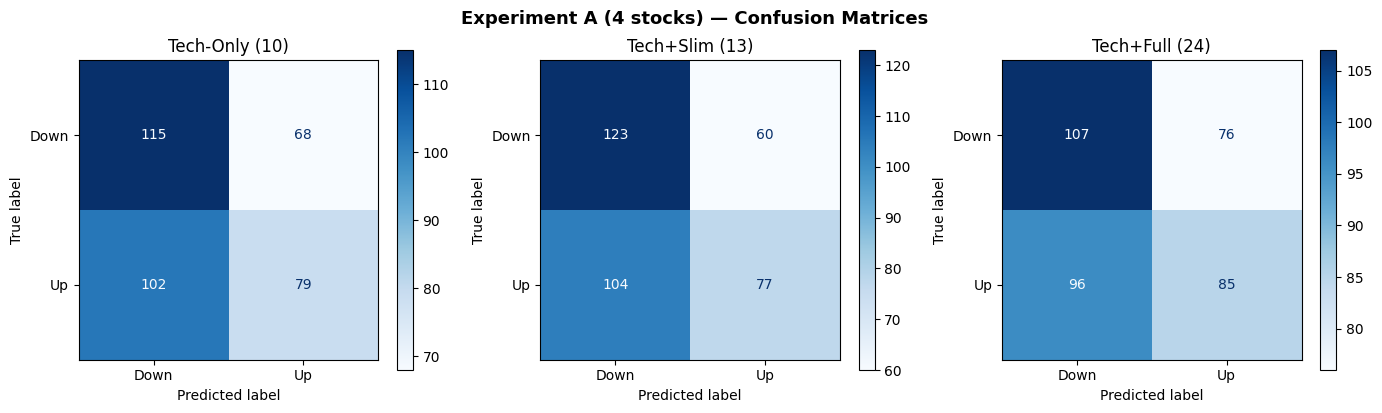

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

y_test_4 = test_4['target'].values
feat_labels = list(FEATURE_SETS.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, fl in zip(axes, feat_labels):
    ConfusionMatrixDisplay.from_predictions(
        y_test_4, models_4[fl]['y_pred'],
        display_labels=['Down', 'Up'], ax=ax, cmap='Blues')
    ax.set_title(fl)

fig.suptitle('Experiment A (4 stocks) — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'expA_confusion.png'), dpi=150)
plt.show()

### A-3. Feature Importance

观察 `Tech+Slim` 模型中情感特征的重要性排位。

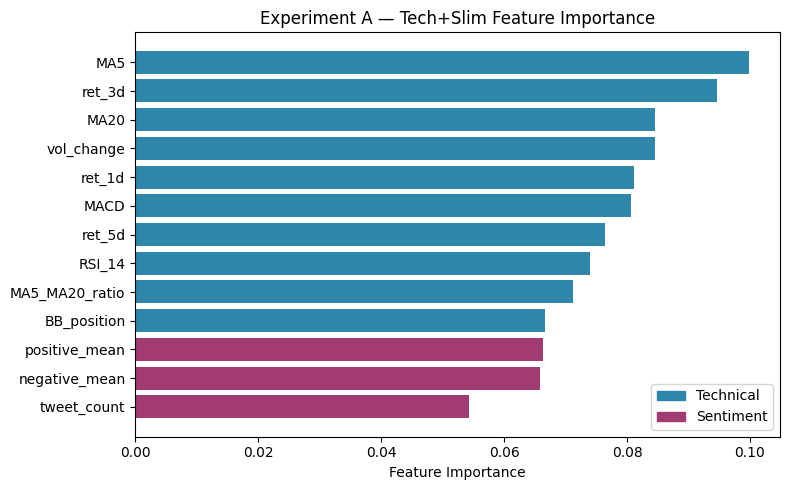

=== Feature Importance ===
  [T] MA5                       0.0999
  [T] ret_3d                    0.0946
  [T] MA20                      0.0846
  [T] vol_change                0.0845
  [T] ret_1d                    0.0812
  [T] MACD                      0.0807
  [T] ret_5d                    0.0764
  [T] RSI_14                    0.0739
  [T] MA5_MA20_ratio            0.0712
  [T] BB_position               0.0667
  [S] positive_mean             0.0663
  [S] negative_mean             0.0659
  [S] tweet_count               0.0542


In [11]:
from matplotlib.patches import Patch

slim_model = models_4['Tech+Slim (13)']['model']
slim_cols = TECH_COLS + SENT_SLIM
imp_df = pd.DataFrame({'feature': slim_cols, 'importance': slim_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

colors = ['#2e86ab' if f in TECH_COLS else '#a23b72' for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(imp_df)), imp_df['importance'].values, color=colors)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Experiment A — Tech+Slim Feature Importance')
ax.legend(handles=[Patch(color='#2e86ab', label='Technical'),
                   Patch(color='#a23b72', label='Sentiment')],
          loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'expA_importance.png'), dpi=150)
plt.show()

print('=== Feature Importance ===')
for _, row in imp_df.iterrows():
    tag = '[T]' if row['feature'] in TECH_COLS else '[S]'
    print(f'  {tag} {row["feature"]:25s} {row["importance"]:.4f}')

### A-4. Conclusion

在 4 只高推文覆盖率（~94%）的股票上：

- **`Tech+Slim (13)` 相比 `Tech-Only (10)` 在 Accuracy、MCC、AUC 上均有提升**，说明精简的情感特征（`positive_mean`, `negative_mean`, `tweet_count`）对 Random Forest 有正向贡献
- **`Tech+Full (24)` 不优于 `Tech+Slim (13)`**，14 维完整情感统计中大部分是冗余的（如 `positive_mean` 与 `positive_median` 高度相关），过多冗余特征反而引入噪声

---
## **实验 B**

将股票池扩展到 StockNet 的全部 87 只股票，测试情感特征在更大规模下的效果。87 只股票中包含大量关注度较低的股票（如公用事业、工业股），**推文覆盖率预期显著下降**。覆盖率不足时，缺失的情感特征由默认值填充（概率 = 1/3, `tweet_count` = 0），相当于引入无信息噪声。

In [12]:
df_87, train_87, test_87 = prepare_dataset(PRICE_DIR, CACHE_DIR, stocks=None)

print(f'Stocks: {df_87["stock"].nunique()}')
print(f'Date:   {df_87["date"].min().date()} ~ {df_87["date"].max().date()}')
print(f'Train:  {len(train_87)},  Test: {len(test_87)}')
print(f'Sentiment coverage (train): {train_87["tweet_count"].gt(0).mean():.1%}')
print(f'Sentiment coverage (test):  {test_87["tweet_count"].gt(0).mean():.1%}')
print(f'Label (train): up={train_87["target"].sum()} ({train_87["target"].mean():.1%}), '
      f'down={(train_87["target"]==0).sum()} ({1-train_87["target"].mean():.1%})')
print(f'Label (test):  up={test_87["target"].sum()} ({test_87["target"].mean():.1%}), '
      f'down={(test_87["target"]==0).sum()} ({1-test_87["target"].mean():.1%})')

Stocks: 87
Date:   2014-01-02 ~ 2015-12-31
Train:  33649,  Test: 8456
Sentiment coverage (train): 44.9%
Sentiment coverage (test):  45.5%
Label (train): up=17243 (51.2%), down=16406 (48.8%)
Label (test):  up=4102 (48.5%), down=4354 (51.5%)


### B-1. Model Performance

In [13]:
res_87, models_87 = run_experiment(train_87, test_87, FEATURE_SETS)

print('=== 实验 B: 87 stocks — Train/Test ===')
print(res_87[display_cols].to_string(index=False, float_format='{:.4f}'.format))

=== 实验 B: 87 stocks — Train/Test ===
      Features  Accuracy  Precision  Recall     F1    MCC    AUC
Tech-Only (10)    0.4967     0.4877  0.7450 0.5895 0.0088 0.5130
Tech+Slim (13)    0.4974     0.4886  0.7738 0.5990 0.0128 0.5126
Tech+Full (24)    0.4939     0.4865  0.7840 0.6004 0.0054 0.5085


### B-2. Confusion Matrices

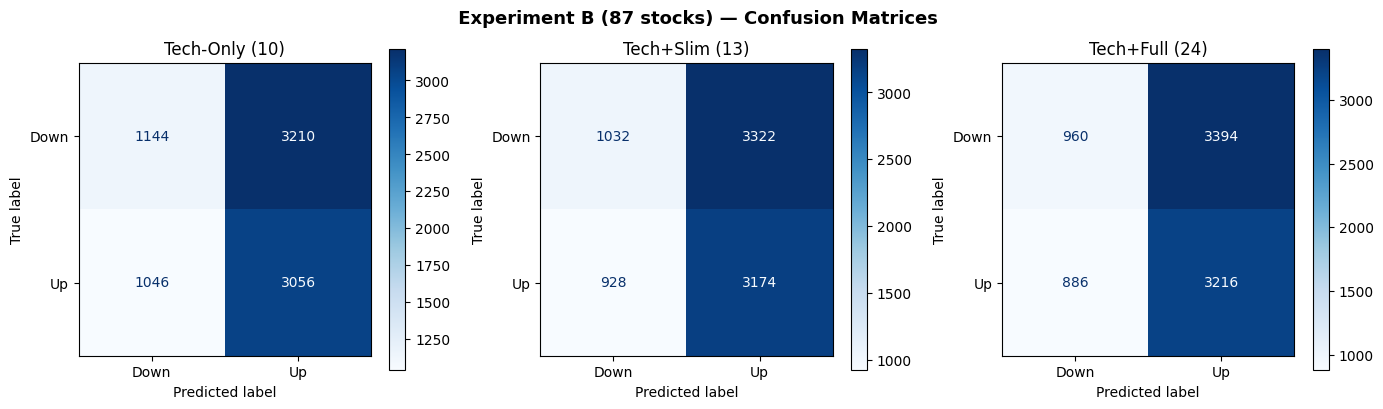

In [18]:
y_test_87 = test_87['target'].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, fl in zip(axes, feat_labels):
    ConfusionMatrixDisplay.from_predictions(
        y_test_87, models_87[fl]['y_pred'],
        display_labels=['Down', 'Up'], ax=ax, cmap='Blues')
    ax.set_title(fl)

fig.suptitle(' Experiment B (87 stocks) — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'expB_confusion.png'), dpi=150)
plt.show()

### B-3. Conclusion

在 87 只股票上，**三组特征的各项指标几乎无差异，情感特征的提升效果消失。** 核心原因是 **推文覆盖率从 ~94%（4 股）降至 ~45%（87 股）**。超过一半的 stock-day 没有推文，情感特征被默认值（1/3）填充，模型无法从中学到有效信号。大量的恒定填充值反而稀释了真实的情感信息。

---
## **实验 C:**

实验 B 中约 55% 的 stock-day 缺少推文，情感特征由默认值填充。此前统一使用 **均匀分布（1/3, 1/3, 1/3）**，但这引发一个问题：模型无法区分"真实的中性情感"和"数据缺失"。本实验在 87 只股票上固定使用 `Tech+Slim (13)` 特征组，仅改变缺失情感的填充策略：

| 填充策略 | positive | negative | neutral | 语义 |
|----------|----------|----------|---------|------|
| **Uniform** | 1/3 | 1/3 | 1/3 | 均匀分布（现有默认） |
| **Zero** | 0 | 0 | 0 | "无情感信号" |
| **Neutral** | 0 | 1 | 0 | 显式标记为中性 |

`tweet_count = 0`、`rel_volume = 1.0` 在三种策略中保持一致。其余所有条件（技术指标、模型超参数、数据划分）完全不变。

In [16]:
FILL_STRATEGIES = {
    'Uniform (1/3)': {'positive_mean': 1/3, 'negative_mean': 1/3},
    'Zero (0/0/0)':  {'positive_mean': 0.0, 'negative_mean': 0.0},
    'Neutral (0/1/0)': {'positive_mean': 0.0, 'negative_mean': 1.0},
}


def prepare_dataset_with_fill(price_dir, cache_dir, fill_defaults, stocks=None):
    """Same as prepare_dataset() but with configurable sentiment fill values."""
    prices = load_price_data(price_dir, stocks)
    prices = compute_technical_indicators(prices)
    prices[TECH_COLS] = prices[TECH_COLS].replace([np.inf, -np.inf], np.nan)
    prices = prices.dropna(subset=TECH_COLS).reset_index(drop=True)

    sent = pd.read_pickle(os.path.join(cache_dir, 'daily_sentiment.pkl'))
    sent['date'] = pd.to_datetime(sent['date'])
    df = prices.merge(sent[['stock', 'date'] + SENT_FULL],
                      on=['stock', 'date'], how='left')

    # Apply fill strategy for slim sentiment columns
    defaults = {c: 1/3 for c in SENT_FULL
                if c.startswith(('positive', 'negative', 'neutral'))}
    defaults['tweet_count'] = 0
    defaults['rel_volume'] = 1.0
    # Override positive_mean and negative_mean with the given strategy
    defaults.update(fill_defaults)
    df[SENT_FULL] = df[SENT_FULL].fillna(defaults)

    df = df[(df['date'] >= '2014-01-01') & (df['date'] <= '2015-12-31')]

    df['target'] = (df.groupby('stock')['movement_pct'].shift(-1) > 0).astype(int)
    df = df.dropna(subset=TECH_COLS + ['target']).reset_index(drop=True)
    df['target'] = df['target'].astype(int)

    train_list, test_list = [], []
    for stock, group in df.groupby('stock'):
        n = len(group)
        split_idx = int(n * 0.8)
        train_list.append(group.iloc[:split_idx])
        test_list.append(group.iloc[split_idx:])
    train_df = pd.concat(train_list, ignore_index=True)
    test_df = pd.concat(test_list, ignore_index=True)

    return df, train_df, test_df

In [17]:
slim_feature_set = {'Tech+Slim (13)': TECH_COLS + SENT_SLIM}

rows = []
for strategy_name, fill_vals in FILL_STRATEGIES.items():
    print(f'\n--- Fill strategy: {strategy_name} ---')
    _, train_tmp, test_tmp = prepare_dataset_with_fill(
        PRICE_DIR, CACHE_DIR, fill_defaults=fill_vals, stocks=None)
    print(f'  Train: {len(train_tmp)},  Test: {len(test_tmp)}')

    res_tmp, _ = run_experiment(train_tmp, test_tmp, slim_feature_set)
    res_tmp['Fill Strategy'] = strategy_name
    rows.append(res_tmp)

fill_results = pd.concat(rows, ignore_index=True)

print('\n=== 实验 C: 填充策略对比 (87 stocks, Tech+Slim) ===')
print(fill_results[['Fill Strategy', 'Accuracy', 'Precision', 'Recall',
                     'F1', 'MCC', 'AUC']].to_string(index=False, float_format='{:.4f}'.format))


--- Fill strategy: Uniform (1/3) ---
  Train: 33649,  Test: 8456

--- Fill strategy: Zero (0/0/0) ---
  Train: 33649,  Test: 8456

--- Fill strategy: Neutral (0/1/0) ---
  Train: 33649,  Test: 8456

=== 实验 C: 填充策略对比 (87 stocks, Tech+Slim) ===
  Fill Strategy  Accuracy  Precision  Recall     F1    MCC    AUC
  Uniform (1/3)    0.4974     0.4886  0.7738 0.5990 0.0128 0.5126
   Zero (0/0/0)    0.5017     0.4912  0.7657 0.5985 0.0216 0.5139
Neutral (0/1/0)    0.4969     0.4881  0.7621 0.5951 0.0107 0.5136


---
### **Limitation**

- **4 只股票的实验仅有 364 条测试样本**，统计显著性有限。但我们选择 4 只股票并非出于随意，而是有意为之的实验设计：AAPL、AMZN、BABA、GOOG 均为高关注度的科技 / 互联网股票，Twitter 上的讨论量远高于一般标的，推文覆盖率接近 100%。这一设置的目的是**控制变量**。在情感数据几乎完整的理想条件下，隔离情感特征本身对预测效果的贡献，排除数据缺失所带来的混淆因素。如果在这一理想条件下情感特征都无法带来改善，那么在更大规模、覆盖率更低的股票池中就更不值得尝试。事实上，实验 A 与实验 B 的对比正好验证了这一逻辑：当覆盖率从 ~94% 降至 ~45%，情感特征的正向贡献几乎归零。这种"先在最有利条件下验证，再扩展到一般条件"的两阶段实验设计，使我们能够区分"情感特征本身无效"和"情感数据不足导致无效"这两种截然不同的结论。

- **所有模型的绝对性能接近随机水平（MCC < 0.15）**，这与股价预测领域的普遍研究发现一致。次日涨跌受宏观经济事件、机构资金流动、市场微观结构等大量不可观测因素驱动，仅凭历史技术指标和公开社交媒体情感难以获得较高的预测准确率。此外，本实验为确保 ablation 的公平性，直接沿用了 E1 baseline 的 Random Forest 超参数（`max_depth=8, n_estimators=200` 等），未针对加入情感特征后的新特征空间进行超参数调优；同时，我们仅使用了 Random Forest 这一传统机器学习模型，未引入 LSTM 等能够建模时序依赖关系的深度学习架构。这些设计选择意味着当前结果是情感特征贡献的**下界估计**。更充分的超参数搜索或更强的模型架构有望进一步放大情感特征的增益。然而，本实验的核心目标并非构建一个可直接用于交易的高性能预测模型，而是通过严格的 ablation study 验证情感特征的**增量贡献**。我们关注的是 Δ metrics（加入情感前后的指标变化），而非绝对指标值本身。在相同的模型架构、超参数和数据划分下，唯一的变量是输入特征集，因此指标的变化可以归因于情感特征的加入。即便在未调参、未使用深度模型的保守条件下，Tech+Slim 相对 Tech-Only 在多项指标上仍有一致性提升（实验 A 中 ΔAcc = +1.6%, ΔMCC = +3.5%, ΔAUC = +1.8%），表明情感信息在数据充分时能够为模型提供额外的预测信号。
